<a id="title"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:20px 20px;">**Centerline Extraction: Hybrid Approach**</p>

## Method Overview: Automated Hybrid Centerline Extraction

This notebook implements a **fully automated, hybrid approach** for coronary artery centerline extraction. It combines two complementary techniques:

1. **Voxel-based topological thinning** (adapted from Maren Clapers' work) — used as an automated "scout" to separate the RCA and LCA arteries and discover seed points (ostium and branch tips) without any manual interaction.
2. **VMTK Voronoi-based centerline extraction** — the mathematically precise algorithm that computes smooth centerlines with **maximum inscribed sphere radii**, the key quantity for downstream stenosis quantification.

### Why a Hybrid?

| Approach | Strength | Weakness |
|----------|----------|----------|
| **Skeletonization (Maren)** | Fully automatic, finds all endpoints | Produces only voxel-resolution coordinates, no inscribed radius |
| **VMTK Centerlines (Oscar)** | Mathematically smooth, provides inscribed radii | Requires manual seed point selection |

By using skeletonization to **automate the seed selection** and then feeding those seeds into VMTK, we get the best of both worlds: a **fully automated pipeline** that outputs clinically useful centerlines with radius data.

### Workflow

```
 .nrrd Binary Mask
        │
        ▼
 ┌──────────────────────────┐
 │  vmtkImageReader          │──► VTK Image ──► NumPy Array
 └────────────┬─────────────┘
              │
              ▼
 ┌──────────────────────────┐
 │  scipy.ndimage.label      │──► Connected Components
 │  center_of_mass (X-axis)  │──► RCA / LCA identification
 └──────┬──────────┬────────┘
        │          │
       RCA        LCA          ◄── same pipeline runs for each
        │          │
        ▼          ▼
 ┌──────────────────────────┐
 │  SCOUT (Phase 2)          │
 │   skeletonize_3d          │──► 1-voxel skeleton
 │   find endpoints          │──► voxels with 1 neighbour
 │   distance_transform_edt  │──► endpoint deepest inside = Ostium
 │   voxel → physical mm     │──► Source + Targets
 └────────────┬─────────────┘
              │
              ▼
 ┌──────────────────────────┐
 │  VMTK (Phase 3)           │
 │   vmtkMarchingCubes       │──► smooth surface mesh
 │   vmtkSurfaceSmoothing    │
 │   vmtkCenterlines         │──► points + inscribed radii
 └────────────┬─────────────┘
              │
              ▼
 ┌──────────────────────────┐
 │  Pandas DataFrame         │
 │   Sample_ID, Artery_Type  │
 │   Px, Py, Pz, Radius     │
 └──────────────────────────┘
```

<a id="step1"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">1. Imports & Configuration</p>

In [1]:
import sys
import types
from pathlib import Path

import numpy as np
import pandas as pd
import pyvista as pv
import scipy.ndimage as ndi
from skimage.morphology import skeletonize
from vtkmodules.util.numpy_support import vtk_to_numpy, numpy_to_vtk
from vtkmodules.vtkCommonDataModel import vtkImageData
from vmtk import vmtkscripts

# The vmtk conda-forge build strips vtkRenderingMatplotlib.
# Inject a dummy so PyVista skips it gracefully.
sys.modules.setdefault(
    "vtkmodules.vtkRenderingMatplotlib",
    types.ModuleType("vtkmodules.vtkRenderingMatplotlib"),
)

<module 'vtkmodules.vtkRenderingMatplotlib'>

In [2]:
SAMPLE_ID = 1
DATA_ROOT = Path("../data/ASOCA Normal")
NRRD_PATH = DATA_ROOT / "Annotations" / f"Normal_{SAMPLE_ID}.nrrd"

for _backend in ("trame", "static"):
    try:
        pv.set_jupyter_backend(_backend)
        break
    except Exception:
        continue

print(f"Sample : Normal_{SAMPLE_ID}")
print(f"Path   : {NRRD_PATH}")
print(f"Exists : {NRRD_PATH.exists()}")

Sample : Normal_1
Path   : ..\data\ASOCA Normal\Annotations\Normal_1.nrrd
Exists : True


<a id="step2"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">2. Phase 1: Mask Loading & RCA/LCA Separation</p>

The ASOCA binary mask contains the **entire coronary artery tree** — both the Right Coronary Artery (RCA) and the Left Coronary Artery (LCA) — in a single label. Before we can process each artery independently, we need to:

1. **Load the mask** with `vmtkImageReader` to retain VTK spatial metadata (spacing, origin).
2. **Convert** the VTK image to a NumPy array using `vtk_to_numpy` for image-processing operations.
3. **Label connected components** using `scipy.ndimage.label` — the RCA and LCA are physically disconnected in the segmentation, so they appear as separate 3D blobs.
4. **Identify** which component is the RCA and which is the LCA using their **center of mass**: in standard CT patient coordinates, the RCA sits to the patient's right (lower physical X-coordinate) and the LCA to the patient's left (higher physical X-coordinate).

This separation logic is adapted from Maren Clapers' `rca_lca_separation.ipynb`.

In [3]:
# ── 2a. Load the mask with VMTK (retains spacing & origin) ──────────────
reader = vmtkscripts.vmtkImageReader()
reader.InputFileName = str(NRRD_PATH)
reader.Execute()

vtk_image = reader.Image
spacing = np.array(vtk_image.GetSpacing())   # (sx, sy, sz) mm
origin  = np.array(vtk_image.GetOrigin())    # (ox, oy, oz) mm
dims    = vtk_image.GetDimensions()          # (nx, ny, nz)

print(f"Dimensions : {dims}")
print(f"Spacing    : {spacing}")
print(f"Origin     : {origin}")

# ── 2b. Convert VTK image → NumPy array in (Z, Y, X) order ─────────────
vtk_scalars = vtk_image.GetPointData().GetScalars()
mask_flat = vtk_to_numpy(vtk_scalars)
mask = mask_flat.reshape(dims[2], dims[1], dims[0]).astype(np.uint8)

print(f"\nNumPy mask shape (Z, Y, X) : {mask.shape}")
print(f"Labeled voxels             : {np.count_nonzero(mask):,}")

# ── 2c. Separate connected components ───────────────────────────────────
labeled, num_components = ndi.label(mask)
print(f"Connected components found : {num_components}")

# Keep only the two largest (ignore small noise fragments)
component_sizes = ndi.sum(mask, labeled, range(1, num_components + 1))
sorted_labels = np.argsort(component_sizes)[::-1] + 1   # largest first, 1-indexed
label_a, label_b = sorted_labels[0], sorted_labels[1]

# ── 2d. Identify RCA vs LCA by center-of-mass physical X ───────────────
com_a = ndi.center_of_mass(mask, labeled, label_a)  # (z, y, x) voxel indices
com_b = ndi.center_of_mass(mask, labeled, label_b)

phys_x_a = origin[0] + com_a[2] * spacing[0]
phys_x_b = origin[0] + com_b[2] * spacing[0]

# RCA sits at lower physical X (patient's right)
if phys_x_a < phys_x_b:
    rca_label, lca_label = label_a, label_b
else:
    rca_label, lca_label = label_b, label_a

artery_arrays = {
    "RCA": (labeled == rca_label).astype(np.uint8),
    "LCA": (labeled == lca_label).astype(np.uint8),
}

for name, arr in artery_arrays.items():
    com = ndi.center_of_mass(arr)
    phys_x = origin[0] + com[2] * spacing[0]
    print(f"\n{name}: {np.count_nonzero(arr):,} voxels  |  "
          f"center-of-mass physical X = {phys_x:.1f} mm")

Spacing 0.416016 0.416016 0.625000
Origin 116.800003 120.000000 -196.875000
Dimensions 512 512 204
Dimensions : (512, 512, 204)
Spacing    : [0.416016 0.416016 0.625   ]
Origin     : [ 116.80000305  120.         -196.875     ]

NumPy mask shape (Z, Y, X) : (204, 512, 512)
Labeled voxels             : 36,104
Connected components found : 2

RCA: 19,946 voxels  |  center-of-mass physical X = 199.3 mm

LCA: 16,158 voxels  |  center-of-mass physical X = 249.9 mm


<a id="step3"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">3. Phase 2 & 3 — Automated Seed Extraction + VMTK Centerlines</p>

For each artery (RCA and LCA) we run the **core hybrid pipeline**:

**Phase 2 — The Scout (Automated Seed Points):**
1. **3D Skeletonization** (`skimage.skeletonize_3d`): Morphologically thins the binary mask down to a 1-voxel-thick skeleton, preserving topology. Adapted from Maren's `Skeletonization.ipynb`.
2. **Endpoint detection**: Skeleton voxels with exactly **1 neighbour** in a 3x3x3 cube are endpoints — they correspond to the ostium or distal branch tips.
3. **Ostium identification via Distance Transform**: `scipy.ndimage.distance_transform_edt` gives the Euclidean distance of each voxel to the nearest mask boundary. The endpoint with the **largest distance** sits deepest inside the thickest part of the vessel — the ostium. All other endpoints become targets.
4. **Coordinate conversion**: Voxel indices `(z, y, x)` are converted to physical mm using the VMTK Image origin and spacing (adapted from Maren's `voxels_to_points_df.ipynb`).

**Phase 3 — Mathematical Centerline (VMTK):**
1. Convert the single-artery NumPy mask back to a VTK image.
2. Run `vmtkMarchingCubes` + `vmtkSurfaceSmoothing` to build a smooth surface.
3. Snap the automated seed points to the nearest mesh vertex for robustness.
4. Feed them into `vmtkCenterlines` for exact Voronoi-based extraction.
5. Extract centerline coordinates and `MaximumInscribedSphereRadius` into a DataFrame.

In [4]:
# ═══════════════════════════════════════════════════════════════
#  Helper functions used by the main processing loop
# ═══════════════════════════════════════════════════════════════

def find_skeleton_endpoints(skeleton):
    """Find endpoints of a 3D skeleton (voxels with exactly 1 neighbour)."""
    kernel = np.ones((3, 3, 3), dtype=int)
    kernel[1, 1, 1] = 0                    # exclude the center voxel itself
    neighbor_count = ndi.convolve(
        skeleton.astype(int), kernel, mode="constant", cval=0
    )
    endpoint_mask = (skeleton > 0) & (neighbor_count == 1)
    return np.argwhere(endpoint_mask)       # (N, 3) array of [z, y, x] indices


def identify_ostium(endpoints_zyx, binary_mask):
    """Return the index of the endpoint deepest inside the vessel (max EDT)."""
    dist_transform = ndi.distance_transform_edt(binary_mask)
    dists = dist_transform[
        endpoints_zyx[:, 0], endpoints_zyx[:, 1], endpoints_zyx[:, 2]
    ]
    return np.argmax(dists), dists


def voxel_to_physical(coords_zyx, img_origin, img_spacing):
    """Convert voxel indices (z, y, x) → physical coordinates (X, Y, Z) mm."""
    phys_x = img_origin[0] + coords_zyx[:, 2] * img_spacing[0]
    phys_y = img_origin[1] + coords_zyx[:, 1] * img_spacing[1]
    phys_z = img_origin[2] + coords_zyx[:, 0] * img_spacing[2]
    return np.column_stack([phys_x, phys_y, phys_z])


def numpy_to_vtk_image(array_zyx, img_spacing, img_origin):
    """Pack a (Z, Y, X) NumPy array into a vtkImageData with correct metadata."""
    nz, ny, nx = array_zyx.shape
    vtk_img = vtkImageData()
    vtk_img.SetDimensions(nx, ny, nz)
    vtk_img.SetSpacing(float(img_spacing[0]), float(img_spacing[1]), float(img_spacing[2]))
    vtk_img.SetOrigin(float(img_origin[0]), float(img_origin[1]), float(img_origin[2]))
    # C-order flatten of (Z,Y,X) gives X-varies-fastest, matching VTK layout
    flat = np.ascontiguousarray(array_zyx.flatten(), dtype=np.float64)
    vtk_arr = numpy_to_vtk(flat)
    vtk_arr.SetName("ImageScalars")
    vtk_img.GetPointData().SetScalars(vtk_arr)
    return vtk_img


def snap_seed_to_surface(mesh, point, inward_fraction=0.3):
    """
    Project a seed point onto the mesh surface, then nudge it slightly inward
    along the vertex normal so it sits inside the tubular geometry.

    VMTK's Voronoi-based centerline tracer needs seeds that lie *on or just
    inside* the surface.  A naive closest-vertex snap can land on the outer
    shell, causing "no steepest descent edge" failures.
    """
    idx = mesh.find_closest_point(point)
    surface_pt = mesh.points[idx].copy()

    if mesh.point_normals is not None:
        normal = mesh.point_normals[idx]
    else:
        mesh_with_normals = mesh.compute_normals(
            point_normals=True, cell_normals=False, consistent_normals=True,
        )
        normal = mesh_with_normals.point_normals[idx]

    norm_len = np.linalg.norm(normal)
    if norm_len < 1e-12:
        return surface_pt.tolist()

    normal = normal / norm_len

    edges = mesh.extract_feature_edges(
        boundary_edges=False, non_manifold_edges=False,
        feature_edges=False, manifold_edges=True,
    )
    if edges.n_points > 1:
        avg_edge_len = np.mean(np.linalg.norm(np.diff(edges.points[:100], axis=0), axis=1))
    else:
        avg_edge_len = np.mean(mesh.spacing) if hasattr(mesh, "spacing") else 0.2

    to_center = np.array(point, dtype=float) - surface_pt
    if np.dot(to_center, normal) > 0:
        inward_normal = normal
    else:
        inward_normal = -normal

    nudged = surface_pt + inward_fraction * avg_edge_len * inward_normal

    final_idx = mesh.find_closest_point(nudged)
    return mesh.points[final_idx].tolist()

In [5]:
all_centerlines_data = []

for artery_name, artery_mask in artery_arrays.items():

    print(f"\n{'=' * 65}")
    print(f"  Processing: {artery_name}")
    print(f"{'=' * 65}")

    # ── PHASE 2 — Scout: skeleton-based automated seed extraction ───

    print("\n[Scout] Running 3D skeletonization …")
    skeleton = skeletonize(artery_mask)
    print(f"[Scout] Skeleton voxels : {np.count_nonzero(skeleton):,}")

    endpoints_zyx = find_skeleton_endpoints(skeleton)
    print(f"[Scout] Endpoints found : {len(endpoints_zyx)}")

    if len(endpoints_zyx) < 2:
        print(f"[Scout] WARNING — fewer than 2 endpoints; skipping {artery_name}.")
        continue

    ostium_idx, dists = identify_ostium(endpoints_zyx, artery_mask)
    print(f"[Scout] Ostium = endpoint #{ostium_idx}  "
          f"(EDT = {dists[ostium_idx]:.2f} voxels)")

    # Source = ostium; targets = all remaining endpoints
    source_zyx  = endpoints_zyx[ostium_idx : ostium_idx + 1]
    target_mask = np.ones(len(endpoints_zyx), dtype=bool)
    target_mask[ostium_idx] = False
    targets_zyx = endpoints_zyx[target_mask]

    # Convert voxel indices → physical mm
    source_phys  = voxel_to_physical(source_zyx,  origin, spacing)
    targets_phys = voxel_to_physical(targets_zyx, origin, spacing)

    print(f"[Scout] Source  (mm)  : {source_phys[0]}")
    print(f"[Scout] Targets       : {len(targets_phys)} branch tips")

    # ── PHASE 3a — Build a smooth surface mesh via VMTK ─────────────

    print("\n[Mesh] NumPy → VTK → Marching Cubes → Smoothing …")
    vtk_artery = numpy_to_vtk_image(artery_mask, spacing, origin)

    mc = vmtkscripts.vmtkMarchingCubes()
    mc.Image = vtk_artery
    mc.Level = 0.5
    mc.Execute()

    smoother = vmtkscripts.vmtkSurfaceSmoothing()
    smoother.Surface = mc.Surface
    smoother.NumberOfIterations = 20
    smoother.PassBand = 0.1
    smoother.Execute()

    surface_smooth = smoother.Surface
    mesh_smooth = pv.wrap(surface_smooth)
    print(f"[Mesh] Surface : {mesh_smooth.n_points:,} vertices, "
          f"{mesh_smooth.n_cells:,} triangles")

    # Snap seeds to surface and nudge inward along vertex normal
    source_flat = snap_seed_to_surface(mesh_smooth, source_phys[0])
    targets_flat = []
    for t in targets_phys:
        targets_flat.extend(snap_seed_to_surface(mesh_smooth, t))

    # ── PHASE 3b — VMTK Centerline Extraction ──────────────────────

    print("\n[VMTK] Extracting centerlines …")
    cl = vmtkscripts.vmtkCenterlines()
    cl.Surface = surface_smooth
    cl.SeedSelectorName = "pointlist"
    cl.SourcePoints = source_flat
    cl.TargetPoints = targets_flat
    cl.AppendEndPoints = 1
    cl.Execute()

    centerlines = pv.wrap(cl.Centerlines)
    cl_points = centerlines.points
    cl_radii  = centerlines.point_data["MaximumInscribedSphereRadius"]

    print(f"[VMTK] Centerline points : {len(cl_points)}")
    print(f"[VMTK] Radius range      : "
          f"[{cl_radii.min():.3f} , {cl_radii.max():.3f}] mm")

    # ── Build per-artery DataFrame ──────────────────────────────────

    df_artery = pd.DataFrame({
        "Sample_ID":   SAMPLE_ID,
        "Artery_Type": artery_name,
        "Px": cl_points[:, 0],
        "Py": cl_points[:, 1],
        "Pz": cl_points[:, 2],
        "Radius": cl_radii,
    })
    all_centerlines_data.append(df_artery)
    print(f"\n[Data] Appended {len(df_artery)} rows for {artery_name}")


  Processing: RCA

[Scout] Running 3D skeletonization …
[Scout] Skeleton voxels : 563
[Scout] Endpoints found : 6
[Scout] Ostium = endpoint #5  (EDT = 3.74 voxels)
[Scout] Source  (mm)  : [ 212.89969905  209.859456   -103.75      ]
[Scout] Targets       : 5 branch tips

[Mesh] NumPy → VTK → Marching Cubes → Smoothing …
[Mesh] Surface : 18,800 vertices, 37,596 triangles

[VMTK] Extracting centerlines …
Cleaning surface.
Triangulating surface.
Computing centerlines.
Computing centerlines...[VMTK] Centerline points : 3990
[VMTK] Radius range      : [0.100 , 2.180] mm

[Data] Appended 3990 rows for RCA

  Processing: LCA

[Scout] Running 3D skeletonization …
[Scout] Skeleton voxels : 708
[Scout] Endpoints found : 10
[Scout] Ostium = endpoint #9  (EDT = 3.32 voxels)
[Scout] Source  (mm)  : [220.80400305 241.892688   -91.875     ]
[Scout] Targets       : 9 branch tips

[Mesh] NumPy → VTK → Marching Cubes → Smoothing …
[Mesh] Surface : 19,086 vertices, 38,172 triangles

[VMTK] Extracting cen

<a id="step4"></a>
# <p style="background-color:green; font-family:calibri; color:white; font-size:120%; text-align:center; border-radius:20px 20px;">4. Export & Visualization</p>

All centerline data from both arteries is now assembled into a single Pandas DataFrame with columns:

| Column | Description |
|--------|-------------|
| **Sample_ID** | Which ASOCA sample this data comes from |
| **Artery_Type** | `"RCA"` or `"LCA"` |
| **Px, Py, Pz** | Physical 3D coordinates (mm) of each centerline point |
| **Radius** | Maximum inscribed sphere radius (mm) — the key quantity for stenosis quantification |

In [6]:
# ── Concatenate all arteries into a single DataFrame ────────────────────
df_centerlines = pd.concat(all_centerlines_data, ignore_index=True)

print(f"Total centerline points : {len(df_centerlines)}")
print(f"  RCA : {(df_centerlines['Artery_Type'] == 'RCA').sum()} points")
print(f"  LCA : {(df_centerlines['Artery_Type'] == 'LCA').sum()} points")
print()
df_centerlines.head(20)

Total centerline points : 7293
  RCA : 3990 points
  LCA : 3303 points



,Sample_ID,Artery_Type,Px,Py,Pz,Radius
0,1,RCA,231.876984,225.600800,-175.701660,0.396656
1,1,RCA,231.789917,225.614838,-175.741364,0.450688
2,1,RCA,231.789536,225.615005,-175.741394,0.450843
3,1,RCA,231.695129,225.656937,-175.749664,0.489475
4,1,RCA,231.635956,225.663040,-175.763458,0.503761
5,1,RCA,231.401581,225.662369,-175.718719,0.520193
6,1,RCA,231.361008,225.662460,-175.693146,0.518145
7,1,RCA,231.336838,225.657578,-175.675217,0.515984
8,1,RCA,230.908340,225.769974,-175.529922,0.497722
9,1,RCA,230.855301,225.792847,-175.534698,0.503001


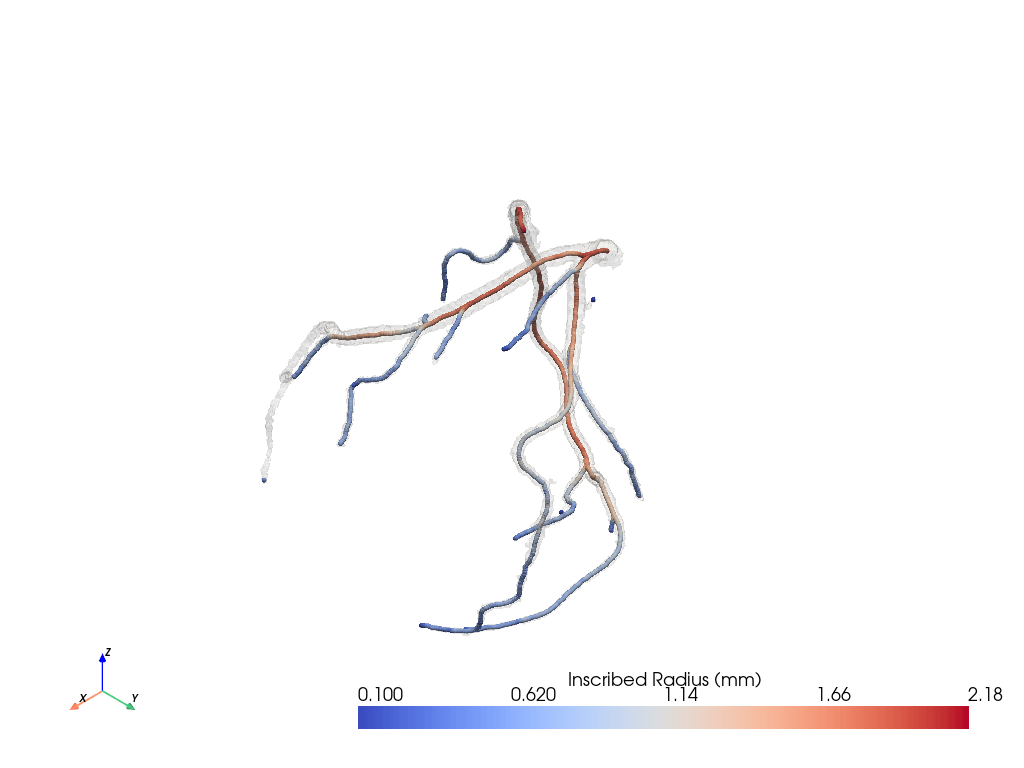

In [7]:
# ── 3D Visualization: translucent vessel mesh + centerlines by radius ───

# Build a surface from the full (unseparated) mask for visual context
vtk_full = numpy_to_vtk_image(mask, spacing, origin)
mc_full = vmtkscripts.vmtkMarchingCubes()
mc_full.Image = vtk_full
mc_full.Level = 0.5
mc_full.Execute()
full_mesh = pv.wrap(mc_full.Surface)

# Assemble centerline point cloud from the DataFrame
cl_pts = df_centerlines[["Px", "Py", "Pz"]].values
cloud = pv.PolyData(cl_pts)
cloud["Radius (mm)"] = df_centerlines["Radius"].values

# Plot
pl = pv.Plotter()
pl.add_mesh(
    full_mesh,
    color="white",
    opacity=0.15,
    show_edges=False,
    label="Vessel surface",
)
pl.add_mesh(
    cloud,
    scalars="Radius (mm)",
    cmap="coolwarm",
    point_size=5,
    render_points_as_spheres=True,
    scalar_bar_args={"title": "Inscribed Radius (mm)", "n_labels": 5},
)
pl.add_axes()
pl.show()